<a href="https://colab.research.google.com/github/nitin-vig/ERAv4S6/blob/main/MNIST_Final_Version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
# This is formatted as code
```

# Improve Model Accuracy.

In [11]:
from __future__ import print_function
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from matplotlib import pyplot as plt

In [12]:
# Train Phase transformations
train_transforms = transforms.Compose([
                                      #  transforms.ColorJitter(brightness=0.10, contrast=0.1, saturation=0.10, hue=0.1),
                                       transforms.ToTensor(),
                                       transforms.Normalize((0.1307,), (0.3081,)) # The mean and std have to be sequences (e.g., tuples), therefore you should add a comma after the values.
                                       # Note the difference between (0.1307) and (0.1307,)
                                       ])

# Test Phase transformations
test_transforms = transforms.Compose([
                                       transforms.ToTensor(),
                                       transforms.Normalize((0.1307,), (0.3081,))
                                       ])

In [13]:
train = datasets.MNIST('./data', train=True, download=True, transform=train_transforms)
test = datasets.MNIST('./data', train=False, download=True, transform=test_transforms)

In [14]:
SEED = 1

# CUDA?
cuda = torch.cuda.is_available()
print("CUDA Available?", cuda)

# For reproducibility
torch.manual_seed(SEED)

if cuda:
    torch.cuda.manual_seed(SEED)

# dataloader arguments - something you'll fetch these from cmdprmt
dataloader_args = dict(shuffle=True, batch_size=128, num_workers=4, pin_memory=True) if cuda else dict(shuffle=True, batch_size=64)

# train dataloader
train_loader = torch.utils.data.DataLoader(train, **dataloader_args)

# test dataloader
test_loader = torch.utils.data.DataLoader(test, **dataloader_args)

CUDA Available? True


In [15]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, 3, padding=0) # 28>26 | 3
        self.bn1 = nn.BatchNorm2d(10)
        self.conv2 = nn.Conv2d(10, 10, 3, padding=0) # 26 > 24 |  5
        self.bn2 = nn.BatchNorm2d(10)
        self.conv3 = nn.Conv2d(10, 20, 3, padding=0) # 24 > 22 |  7
        self.bn3 = nn.BatchNorm2d(20)
        self.pool1 = nn.MaxPool2d(2, 2) # output_size = 11 | 8
        self.squeeze1= nn.Conv2d(in_channels=20, out_channels=10, kernel_size=(1, 1), padding=0, bias=False)
        self.bn4 = nn.BatchNorm2d(10)

        self.conv4 = nn.Conv2d(10, 10, 3, padding=0) # 11>9 | 3
        self.bn5 = nn.BatchNorm2d(10)
        self.conv5 = nn.Conv2d(10, 10, 3, padding=0) # 9 > 7 |  5
        self.bn6 = nn.BatchNorm2d(10)

        self.conv6 = nn.Conv2d(10, 20, 3, padding=0) # 9 > 7 |  5
        self.bn8 = nn.BatchNorm2d(20)

        self.squeeze2= nn.Conv2d(in_channels=20, out_channels=10, kernel_size=(1, 1), padding=0, bias=False)
        self.bn7 = nn.BatchNorm2d(10)
       # self.output= nn.Conv2d(in_channels=10, out_channels=10, kernel_size=(7, 7), padding=0, bias=False)
        self.gap = nn.AvgPool2d(kernel_size=5)
        # self.dropout = nn.Dropout(0.05)

    def forward(self, x):
        # Block 1
        x = self.bn1(F.relu(self.conv1(x)))
        x = self.bn2(F.relu(self.conv2(x)))
        x = self.bn3(F.relu(self.conv3(x)))
        # Transition Block
        x = self.pool1(x)
        x = self.bn4(F.relu((self.squeeze1(x))))

        # Block 2
        x = self.bn5(F.relu(self.conv4(x)))
        x = self.bn6(F.relu(self.conv5(x)))
        x = self.bn8(F.relu(self.conv6(x)))
        # x = self.dropout(x)
        # Output block
        x = self.bn7(F.relu(self.squeeze2(x)))

        # x = self.output(x)
        x = self.gap(x)
        x = x.view(-1, 10)
        return F.log_softmax(x, dim=-1)

In [16]:
!pip install torchsummary
from torchsummary import summary
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print(device)
model = Net().to(device)
summary(model, input_size=(1, 28, 28))

cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 10, 26, 26]             100
       BatchNorm2d-2           [-1, 10, 26, 26]              20
            Conv2d-3           [-1, 10, 24, 24]             910
       BatchNorm2d-4           [-1, 10, 24, 24]              20
            Conv2d-5           [-1, 20, 22, 22]           1,820
       BatchNorm2d-6           [-1, 20, 22, 22]              40
         MaxPool2d-7           [-1, 20, 11, 11]               0
            Conv2d-8           [-1, 10, 11, 11]             200
       BatchNorm2d-9           [-1, 10, 11, 11]              20
           Conv2d-10             [-1, 10, 9, 9]             910
      BatchNorm2d-11             [-1, 10, 9, 9]              20
           Conv2d-12             [-1, 10, 7, 7]             910
      BatchNorm2d-13             [-1, 10, 7, 7]              20
           Conv2d-14             [

In [17]:

model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1) ## Learning: adjust LR to a smaller value after every 5 epochs for fine tuning

In [18]:
from tqdm import tqdm

train_losses = []
test_losses = []
train_acc = []
test_acc = []

def train(model, device, train_loader, optimizer, epoch):
  model.train()
  pbar = tqdm(train_loader)
  correct = 0
  processed = 0
  for batch_idx, (data, target) in enumerate(pbar):
    # get samples
    data, target = data.to(device), target.to(device)

    # Init
    optimizer.zero_grad()
    # In PyTorch, we need to set the gradients to zero before starting to do backpropragation because PyTorch accumulates the gradients on subsequent backward passes.
    # Because of this, when you start your training loop, ideally you should zero out the gradients so that you do the parameter update correctly.

    # Predict
    y_pred = model(data)

    # Calculate loss
    loss = F.nll_loss(y_pred, target)
    train_losses.append(loss)

    # Backpropagation
    loss.backward()
    optimizer.step()

    # Update pbar-tqdm

    pred = y_pred.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
    correct += pred.eq(target.view_as(pred)).sum().item()
    processed += len(data)

    pbar.set_description(desc= f'Loss={loss.item()} Batch_id={batch_idx} Accuracy={100*correct/processed:0.2f}')
    train_acc.append(100*correct/processed)

  # Update the learning rate
  scheduler.step()


def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

    test_acc.append(100. * correct / len(test_loader.dataset))

In [19]:
EPOCHS = 15
for epoch in range(EPOCHS):
    print("EPOCH:", epoch)
    train(model, device, train_loader, optimizer, epoch)
    test(model, device, test_loader)

EPOCH: 0


Loss=0.11613590270280838 Batch_id=468 Accuracy=90.29: 100%|██████████| 469/469 [00:21<00:00, 22.07it/s]



Test set: Average loss: 0.1767, Accuracy: 9609/10000 (96.09%)

EPOCH: 1


Loss=0.07411623746156693 Batch_id=468 Accuracy=97.71: 100%|██████████| 469/469 [00:15<00:00, 30.41it/s]



Test set: Average loss: 0.0687, Accuracy: 9851/10000 (98.51%)

EPOCH: 2


...


Test set: Average loss: 0.0235, Accuracy: 9945/10000 (99.45%)

EPOCH: 13


Loss=0.029029326513409615 Batch_id=468 Accuracy=99.49: 100%|██████████| 469/469 [00:15<00:00, 30.65it/s]



Test set: Average loss: 0.0231, Accuracy: 9944/10000 (99.44%)

EPOCH: 14


Loss=0.021677881479263306 Batch_id=468 Accuracy=99.48: 100%|██████████| 469/469 [00:15<00:00, 30.78it/s]



Test set: Average loss: 0.0236, Accuracy: 9942/10000 (99.42%)



Text(0.5, 1.0, 'Test Accuracy')

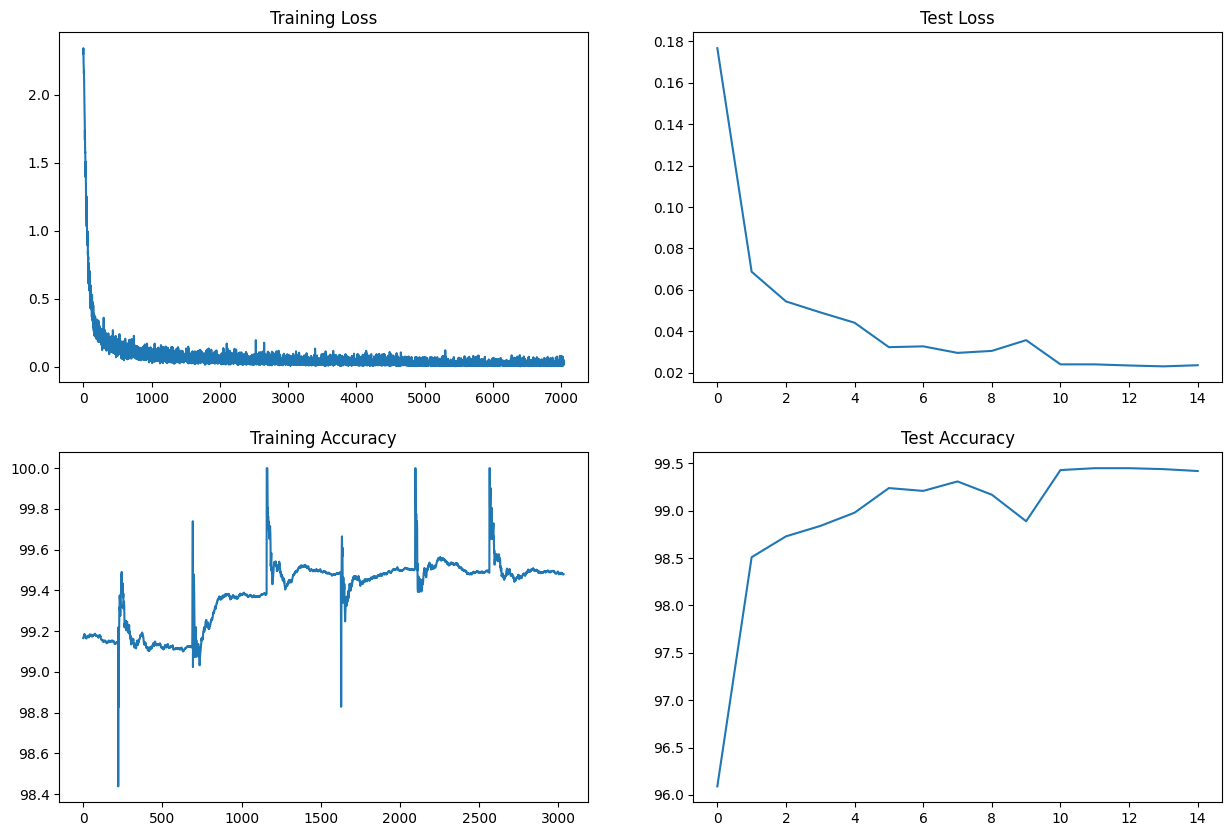

In [20]:
t = [t_items.item() for t_items in train_losses]
%matplotlib inline
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2,2,figsize=(15,10))
axs[0, 0].plot(t)
axs[0, 0].set_title("Training Loss")
axs[1, 0].plot(train_acc[4000:])
axs[1, 0].set_title("Training Accuracy")
axs[0, 1].plot(test_losses)
axs[0, 1].set_title("Test Loss")
axs[1, 1].plot(test_acc)
axs[1, 1].set_title("Test Accuracy")